In [1]:
import pandas, seaborn
import scipy, scipy.stats
import matplotlib, matplotlib.pyplot
matplotlib.rcParams.update({'font.size':20, 
                            'font.family':'sans-serif', 
                            'xtick.labelsize':12, 
                            'ytick.labelsize':8, 
                            'figure.figsize':(16*(2/3), 9*(2/3)), 
                            'axes.labelsize':16
                           })

In [2]:
# user-defined variables
expression_file = '/Users/adrian/research/bmcbf/029_orsay/results/000.quantification/results/DESeq2_TPM_values.tsv'
annotation_file = '/Users/adrian/software/kallisto/mouse_index_standard/annotation.tsv'

In [3]:
# read info
expression = pandas.read_csv(expression_file, sep='\t', index_col=0)
anno = pandas.read_csv(annotation_file, sep='\t')

expression.index = expression.index.str.split('.').str[0]

print(expression.shape)
expression.drop(['P9T001', 'P9T004', 'P9T009'], axis=1, inplace=True)
print(expression.shape)

(34183, 34)
(34183, 31)


In [4]:
input_file = '/Users/adrian/research/bmcbf/029_orsay/results/006.DDBs/DDBs_WT.for.tsv'
df = pandas.read_csv(input_file, sep='\t')
sub = df[df['log2FoldChange'] < 0]
sub.sort_values(by='log2FoldChange')
print(sub.shape)
biomarkers = list(sub.index)

input_file = '/Users/adrian/research/bmcbf/029_orsay/results/006.DDBs/DDBs_HOM.for.tsv'
df = pandas.read_csv(input_file, sep='\t')
sub = df[df['log2FoldChange'] < 0]
sub.sort_values(by='log2FoldChange')
print(sub.shape)
biomarkers = biomarkers + list(sub.index)[:20]
print(len(biomarkers))

input_file = '/Users/adrian/research/bmcbf/029_orsay/results/006.DDBs/DDBs_VGA.for.tsv'
df = pandas.read_csv(input_file, sep='\t')
sub = df[df['log2FoldChange'] < 0]
sub.sort_values(by='log2FoldChange')
print(sub.shape)
biomarkers = biomarkers + list(sub.index)[:20]
print(len(biomarkers), biomarkers)

(11, 12)
(100, 12)
31
(66, 12)
51 ['ENSMUSG00000034394', 'ENSMUSG00000026023', 'ENSMUSG00000030124', 'ENSMUSG00000095366', 'ENSMUSG00000050105', 'ENSMUSG00000096768', 'ENSMUSG00000024261', 'ENSMUSG00000050010', 'ENSMUSG00000092627', 'ENSMUSG00000056296', 'ENSMUSG00000033308', 'ENSMUSG00000040026', 'ENSMUSG00000052415', 'ENSMUSG00000056054', 'ENSMUSG00000056071', 'ENSMUSG00000040809', 'ENSMUSG00000056706', 'ENSMUSG00000061397', 'ENSMUSG00000051748', 'ENSMUSG00000027398', 'ENSMUSG00000031722', 'ENSMUSG00000023041', 'ENSMUSG00000059632', 'ENSMUSG00000026822', 'ENSMUSG00000068893', 'ENSMUSG00000029371', 'ENSMUSG00000063651', 'ENSMUSG00000054905', 'ENSMUSG00000026073', 'ENSMUSG00000039196', 'ENSMUSG00000059108', 'ENSMUSG00000029298', 'ENSMUSG00000073409', 'ENSMUSG00000079017', 'ENSMUSG00000029816', 'ENSMUSG00000105504', 'ENSMUSG00000032690', 'ENSMUSG00000060550', 'ENSMUSG00000025498', 'ENSMUSG00000028037', 'ENSMUSG00000066677', 'ENSMUSG00000020641', 'ENSMUSG00000030107', 'ENSMUSG00000031995

In [5]:
sub

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,ensembl_id,gene_name,biotype,description2,medianTPM_VGA,medianTPM_all
ENSMUSG00000029298,963.425901,-1.042892,0.126642,79.930870,3.877410e-19,4.421798e-15,ENSMUSG00000029298,Gbp9,protein_coding,guanylate-binding protein 9,14.518241,7.308962
ENSMUSG00000073409,460.420868,-2.184872,0.336232,59.166928,1.448479e-14,8.259226e-11,ENSMUSG00000073409,H2-Q6,protein_coding,"histocompatibility 2, Q region locus 6",23.085596,5.779719
ENSMUSG00000079017,1401.920049,-2.150868,0.365117,48.576793,3.176055e-12,1.207324e-08,ENSMUSG00000079017,Ifi27l2a,protein_coding,"interferon, alpha-inducible protein 27 like 2A",494.620385,114.371697
ENSMUSG00000029816,208.132057,-3.035028,0.564342,44.626466,2.384465e-11,6.798111e-08,ENSMUSG00000029816,Gpnmb,protein_coding,glycoprotein (transmembrane) nmb,3.107548,1.064141
ENSMUSG00000105504,218.596218,-1.149312,0.192056,42.504489,7.052019e-11,1.608425e-07,ENSMUSG00000105504,Gbp5,protein_coding,guanylate binding protein 5,5.170663,2.454644
...,...,...,...,...,...,...,...,...,...,...,...,...
ENSMUSG00000040483,1162.543997,-1.058509,0.321136,12.950596,3.198196e-04,4.240956e-02,ENSMUSG00000040483,Xaf1,protein_coding,XIAP associated factor 1,99.042378,41.438418
ENSMUSG00000079055,165.611932,-1.137444,0.347862,12.823219,3.423442e-04,4.487464e-02,ENSMUSG00000079055,Slc8a3,protein_coding,solute carrier family 8 (sodium/calcium exchan...,2.708622,1.216706
ENSMUSG00000034295,256.117097,-1.396318,0.438124,12.740356,3.578497e-04,4.616833e-02,ENSMUSG00000034295,Fhod3,protein_coding,formin homology 2 domain containing 3,6.062421,2.424312
ENSMUSG00000023341,191.751767,-1.311813,0.412342,12.506293,4.055836e-04,4.973415e-02,ENSMUSG00000023341,Mx2,protein_coding,MX dynamin-like GTPase 2,10.883747,3.631400


In [6]:
df = expression.loc[biomarkers]
df

,P9T002,P9T003,P9T005,P9T006,P9T007,P9T008,P9T010,P9T011,P9T012,P9T013,...,P9T025,P9T026,P9T027,P9T028,P9T029,P9T030,P9T031,P9T032,P9T033,P9T034
ENSMUSG00000034394,21.876112,13.571332,42.489780,16.099713,40.681755,14.187001,9.246905,9.334773,10.918618,10.214580,...,7.910788,8.530758,10.094681,14.476410,13.285303,15.558664,6.301973,8.062981,22.638860,9.669246
ENSMUSG00000026023,8.297105,16.833076,12.031429,10.997231,10.411869,10.916543,8.776796,4.670883,8.019623,5.537874,...,5.021607,5.935086,4.320336,6.983708,3.659295,3.987656,3.379811,5.983841,7.674741,7.637204
ENSMUSG00000030124,13.411665,15.231313,22.740764,11.791541,19.025335,8.828053,8.474153,4.727594,8.229261,9.232248,...,4.903183,8.401615,4.620849,3.922125,11.301971,8.231642,6.179308,7.541917,8.124075,6.226719
ENSMUSG00000095366,58.010706,120.038664,52.464723,53.650888,59.290861,60.130795,41.204810,29.492636,40.240697,23.106404,...,37.277714,17.973233,12.010788,16.941173,16.782182,34.389647,25.172342,51.484692,14.636674,58.765472
ENSMUSG00000050105,39.335838,26.577148,38.665982,44.544169,31.412847,21.052179,23.449065,11.264837,32.649012,29.085734,...,10.004530,16.694364,17.060956,12.326064,10.288205,15.191242,12.834090,21.519702,16.843137,18.799414
ENSMUSG00000096768,591.347026,1857.474071,1180.802033,1419.832250,659.107922,1173.600949,401.029499,549.222408,389.236403,575.624442,...,461.263827,231.262062,293.767045,375.642889,229.372294,383.942078,661.279938,633.525175,762.815225,606.372928
ENSMUSG00000024261,9.319895,11.778281,31.657113,4.300244,23.389478,4.169744,6.097160,2.079624,1.370939,1.904266,...,2.051871,2.974581,0.754498,6.368685,4.832966,5.314435,1.213506,2.891289,21.496422,3.610045
ENSMUSG00000050010,4.901589,4.024206,7.700380,1.760675,7.054702,3.234658,1.113767,0.345435,0.741021,1.689050,...,0.470661,1.005153,2.620201,0.400471,2.110919,2.580494,0.693112,1.524528,3.304493,1.446896
ENSMUSG00000092627,2.094639,0.386491,4.664438,2.366788,2.067668,1.787841,1.374095,1.014303,0.517782,0.452921,...,0.901253,0.621483,0.602157,0.696581,0.867563,1.156599,1.000930,1.627570,1.389486,1.691389
ENSMUSG00000056296,10.273691,9.252404,21.879741,5.648290,14.839441,9.528005,4.932094,6.634528,2.358134,2.097811,...,1.358118,1.124795,0.925208,4.368532,14.303296,2.339608,1.492699,4.308653,6.836111,7.232813


In [7]:
label_map = dict(zip(anno['ensembl_gene_id'], anno['external_gene_name']))
df.rename(index=label_map, inplace=True)
df

,P9T002,P9T003,P9T005,P9T006,P9T007,P9T008,P9T010,P9T011,P9T012,P9T013,...,P9T025,P9T026,P9T027,P9T028,P9T029,P9T030,P9T031,P9T032,P9T033,P9T034
Lif,21.876112,13.571332,42.489780,16.099713,40.681755,14.187001,9.246905,9.334773,10.918618,10.214580,...,7.910788,8.530758,10.094681,14.476410,13.285303,15.558664,6.301973,8.062981,22.638860,9.669246
Cdk15,8.297105,16.833076,12.031429,10.997231,10.411869,10.916543,8.776796,4.670883,8.019623,5.537874,...,5.021607,5.935086,4.320336,6.983708,3.659295,3.987656,3.379811,5.983841,7.674741,7.637204
Lag3,13.411665,15.231313,22.740764,11.791541,19.025335,8.828053,8.474153,4.727594,8.229261,9.232248,...,4.903183,8.401615,4.620849,3.922125,11.301971,8.231642,6.179308,7.541917,8.124075,6.226719
G530011O06Riky,58.010706,120.038664,52.464723,53.650888,59.290861,60.130795,41.204810,29.492636,40.240697,23.106404,...,37.277714,17.973233,12.010788,16.941173,16.782182,34.389647,25.172342,51.484692,14.636674,58.765472
Fam110d,39.335838,26.577148,38.665982,44.544169,31.412847,21.052179,23.449065,11.264837,32.649012,29.085734,...,10.004530,16.694364,17.060956,12.326064,10.288205,15.191242,12.834090,21.519702,16.843137,18.799414
Erdr1y,591.347026,1857.474071,1180.802033,1419.832250,659.107922,1173.600949,401.029499,549.222408,389.236403,575.624442,...,461.263827,231.262062,293.767045,375.642889,229.372294,383.942078,661.279938,633.525175,762.815225,606.372928
Syt4,9.319895,11.778281,31.657113,4.300244,23.389478,4.169744,6.097160,2.079624,1.370939,1.904266,...,2.051871,2.974581,0.754498,6.368685,4.832966,5.314435,1.213506,2.891289,21.496422,3.610045
Shisa3,4.901589,4.024206,7.700380,1.760675,7.054702,3.234658,1.113767,0.345435,0.741021,1.689050,...,0.470661,1.005153,2.620201,0.400471,2.110919,2.580494,0.693112,1.524528,3.304493,1.446896
D130058E05Rik,2.094639,0.386491,4.664438,2.366788,2.067668,1.787841,1.374095,1.014303,0.517782,0.452921,...,0.901253,0.621483,0.602157,0.696581,0.867563,1.156599,1.000930,1.627570,1.389486,1.691389
Synpr,10.273691,9.252404,21.879741,5.648290,14.839441,9.528005,4.932094,6.634528,2.358134,2.097811,...,1.358118,1.124795,0.925208,4.368532,14.303296,2.339608,1.492699,4.308653,6.836111,7.232813


In [8]:
df_zscore = df.apply(scipy.stats.zscore, axis=1)
df_zscore

,P9T002,P9T003,P9T005,P9T006,P9T007,P9T008,P9T010,P9T011,P9T012,P9T013,...,P9T025,P9T026,P9T027,P9T028,P9T029,P9T030,P9T031,P9T032,P9T033,P9T034
Lif,0.992191,0.024047,3.395264,0.318797,3.184491,0.095820,-0.480080,-0.469837,-0.285198,-0.367272,...,-0.635841,-0.563567,-0.381250,0.129558,-0.009297,0.255724,-0.823391,-0.618098,1.081109,-0.430845
Cdk15,0.436910,3.315067,1.696049,1.347338,1.149966,1.320132,0.598653,-0.785778,0.343349,-0.493446,...,-0.667521,-0.359514,-0.903975,-0.005940,-1.126865,-1.016148,-1.221101,-0.343075,0.227062,0.214405
Lag3,1.134434,1.556919,3.300463,0.758273,2.437815,0.070211,-0.011958,-0.881833,-0.068816,0.164057,...,-0.841065,-0.028799,-0.906617,-1.068847,0.644605,-0.068264,-0.544774,-0.228404,-0.093239,-0.533767
G530011O06Riky,1.016983,3.931093,0.756429,0.812156,1.077125,1.116586,0.227431,-0.322813,0.182137,-0.622842,...,0.042934,-0.864002,-1.144121,-0.912489,-0.919958,-0.092749,-0.525783,0.710387,-1.020755,1.052442
Fam110d,2.107717,0.749706,2.036418,2.662081,1.264409,0.161639,0.416759,-0.880107,1.395984,1.016715,...,-1.014252,-0.302198,-0.263179,-0.767152,-0.984058,-0.462188,-0.713079,0.211401,-0.286363,-0.078141
Erdr1y,-0.067449,3.217774,1.462011,2.082223,0.108370,1.443327,-0.561266,-0.176750,-0.591866,-0.108245,...,-0.404976,-1.001762,-0.839581,-0.627137,-1.006666,-0.605603,0.114006,0.041991,0.377460,-0.028461
Syt4,0.461031,0.810622,3.637460,-0.252780,2.461774,-0.271338,0.002747,-0.568560,-0.669338,-0.593497,...,-0.572507,-0.441294,-0.756998,0.041359,-0.177026,-0.108559,-0.691725,-0.453139,2.192575,-0.350929
Shisa3,1.443793,0.976066,2.935809,-0.230607,2.591603,0.555164,-0.575469,-0.985061,-0.774177,-0.268789,...,-0.918304,-0.633370,0.227601,-0.955722,-0.043894,0.206434,-0.799717,-0.356495,0.592392,-0.397880
D130058E05Rik,1.032182,-1.043762,4.155307,1.362930,0.999404,0.659325,0.156491,-0.280770,-0.884201,-0.963028,...,-0.418162,-0.758171,-0.781658,-0.666903,-0.459106,-0.107835,-0.297023,0.464545,0.175197,0.542105
Synpr,0.937350,0.726960,3.328250,-0.015504,1.877916,0.783736,-0.163043,0.187666,-0.693291,-0.746919,...,-0.899299,-0.947364,-0.988480,-0.279140,1.767468,-0.697107,-0.871575,-0.291475,0.229193,0.310916


In [9]:
group_dict = {}

# Group A: P9T002 to P9T008 (excluding P9T004 and P9T009)
for i in range(1, 10):
    if i not in [1, 4, 9]:
        sample_id = f"P9T{i:03d}"
        group_dict[sample_id] = "WT"

# Group B: P9T010 to P9T015
for i in range(10, 19):
    sample_id = f"P9T{i:03d}"
    group_dict[sample_id] = "HET"

# Group C: P9T020 to P9T025
for i in range(19, 31):
    sample_id = f"P9T{i:03d}"
    group_dict[sample_id] = "HOM"

for i in range(31, 35):
    sample_id = f"P9T{i:03d}"
    group_dict[sample_id] = "VGA"

group_series = pandas.Series(group_dict).reindex(df_zscore.columns)
group_colors = group_series.map({'WT': 'gray', 'HET': 'gold', 'HOM': 'tab:red', 'VGA': 'skyblue'})

In [10]:
# exclude flat ones. count how many are postive, should be more than two
print(df_zscore.shape)
df_filtered = df_zscore[(df_zscore > 0).sum(axis=1) > 2]
print(df_filtered.shape)

(51, 31)
(48, 31)


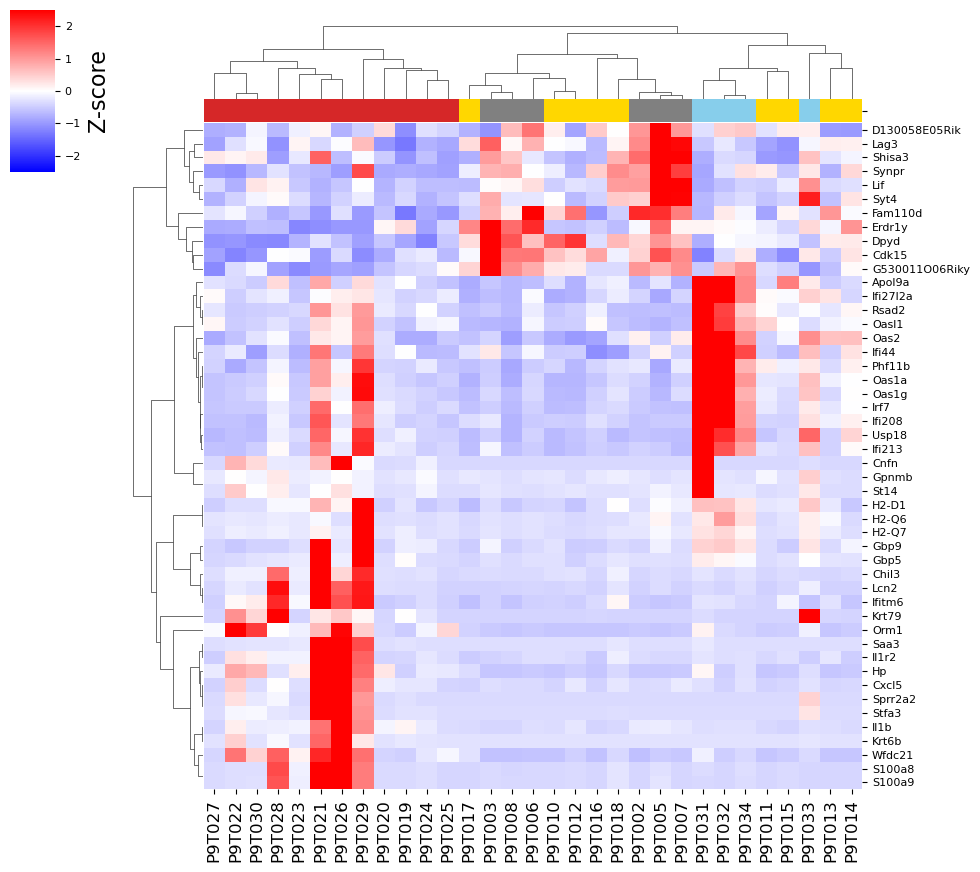

In [11]:
# euclidean ward seems to work fine
# correlation average also seems good
# correlation complete is the best with top 20
# cosine average good
g = seaborn.clustermap(
    df_filtered,
    metric='correlation',     # distance metric
    method='complete',       # clustering method (e.g., single, complete, average, ward)
    cmap='bwr',            # color map (others: 'coolwarm', 'viridis', 'mako', 'rocket')
    standard_scale=None,    # or 0 (rows) or 1 (columns) if you didn't z-score earlier
    figsize=(9, 9),
    col_colors=group_colors,
    #row_colors=row_colors,
    dendrogram_ratio=(0.1, 0.1),  # adjust size of dendrograms
    cbar_pos=(-0.1, 0.8, 0.05, 0.18),  # colorbar position
    xticklabels=True,
    cbar_kws={'label': 'Z-score'},
    vmin=-2.5,
    vmax=2.5,
    yticklabels=True
)
#matplotlib.pyplot.setp(g.ax_heatmap.get_yticklabels(), rotation=0)